In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Load Dataset

In [160]:
data = pd.read_csv("housing.csv")

## Data Preprocessing

In [161]:
data.drop(columns=['longitude', 'latitude'], inplace=True)

In [162]:
data.dropna(inplace=True)

In [163]:
data

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...
20635,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## OneHot Encoding

In [190]:
data['ocean_proximity'].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [192]:
data = pd.get_dummies(data, columns=['ocean_proximity'])

In [193]:
data

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedrooms_per_house,rooms_per_house,population_per_house,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False,1.023810,6.984127,2.555556,False,False,False,True,False
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False,0.971880,6.238137,2.109842,False,False,False,True,False
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False,1.073446,8.288136,2.802260,False,False,False,True,False
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False,1.073059,5.817352,2.547945,False,False,False,True,False
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False,1.081081,6.281853,2.181467,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,False,True,False,False,False,1.133333,5.045455,2.560606,False,True,False,False,False
20636,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,False,True,False,False,False,1.315789,6.114035,3.122807,False,True,False,False,False
20637,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,False,True,False,False,False,1.120092,5.205543,2.325635,False,True,False,False,False
20638,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,False,True,False,False,False,1.171920,5.329513,2.123209,False,True,False,False,False


## Feature Engineering

In [194]:
data['bedrooms_per_house'] = data['total_bedrooms'] / data['households']
data['rooms_per_house'] = data['total_rooms'] / data['households']
data['population_per_house'] = data['population'] / data['households']

In [195]:
data

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedrooms_per_house,rooms_per_house,population_per_house,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False,1.023810,6.984127,2.555556,False,False,False,True,False
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False,0.971880,6.238137,2.109842,False,False,False,True,False
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False,1.073446,8.288136,2.802260,False,False,False,True,False
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False,1.073059,5.817352,2.547945,False,False,False,True,False
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False,1.081081,6.281853,2.181467,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,False,True,False,False,False,1.133333,5.045455,2.560606,False,True,False,False,False
20636,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,False,True,False,False,False,1.315789,6.114035,3.122807,False,True,False,False,False
20637,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,False,True,False,False,False,1.120092,5.205543,2.325635,False,True,False,False,False
20638,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,False,True,False,False,False,1.171920,5.329513,2.123209,False,True,False,False,False


## Remove Outliers

In [196]:
upper_limit = data['bedrooms_per_house'].quantile(0.99)
data = data[data['bedrooms_per_house'] <= upper_limit]

## Cap Values

In [197]:
# Cap rooms_per_house at 10 
data.loc[data['rooms_per_house'] > 10, 'rooms_per_house'] = 10

In [198]:
# Cap population_per_house at 10
data.loc[data['population_per_house'] > 10, 'population_per_house'] = 10

## Features & Targets

In [199]:
X = data.drop(columns = ['median_house_value'])

In [200]:
X

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedrooms_per_house,rooms_per_house,population_per_house,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,False,False,False,True,False,1.023810,6.984127,2.555556,False,False,False,True,False
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,False,False,False,True,False,0.971880,6.238137,2.109842,False,False,False,True,False
2,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,False,True,False,1.073446,8.288136,2.802260,False,False,False,True,False
3,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,False,True,False,1.073059,5.817352,2.547945,False,False,False,True,False
4,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,False,True,False,1.081081,6.281853,2.181467,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,25.0,1665.0,374.0,845.0,330.0,1.5603,False,True,False,False,False,1.133333,5.045455,2.560606,False,True,False,False,False
20636,18.0,697.0,150.0,356.0,114.0,2.5568,False,True,False,False,False,1.315789,6.114035,3.122807,False,True,False,False,False
20637,17.0,2254.0,485.0,1007.0,433.0,1.7000,False,True,False,False,False,1.120092,5.205543,2.325635,False,True,False,False,False
20638,18.0,1860.0,409.0,741.0,349.0,1.8672,False,True,False,False,False,1.171920,5.329513,2.123209,False,True,False,False,False


In [201]:
y = data['median_house_value']

In [202]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Model Training

In [221]:
model = LinearRegression()

In [222]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Prediction on Training Data

In [223]:
train_pred = model.predict(X_train)


In [224]:
train_pred

array([302788.37451763, 232389.24869817, 258994.39560591, ...,
       161376.07264253, 269378.50960019, 347563.36209847], shape=(15859,))

In [225]:
train_r2 = r2_score(y_train, train_pred)
print("R squared error on training data:", train_r2)

R squared error on training data: 0.6519869061480053


## Prediction on Test Data

In [226]:
test_pred = model.predict(X_test)

In [227]:
test_pred

array([351546.61023187, 239399.28783023, 316043.53050612, ...,
       199350.17236271, 397698.97727746, 712497.28638891], shape=(3965,))

In [228]:
test_r2 = r2_score(y_test, test_pred)
print("R squared error on test data:", test_r2)

R squared error on test data: 0.6642072762692154


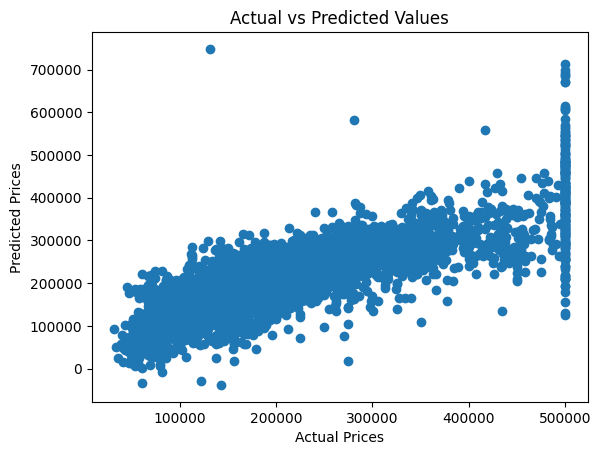

In [229]:
plt.scatter(y_test, test_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Values")
plt.show()

In [230]:
pk.dump(model,open('House_Price_Prediction_Model.pkl','wb'))

In [231]:
data_new.to_csv('cleaned_data.csv')